## Installation and Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Trash_detect

/content/drive/MyDrive/Trash_detect


In [ ]:
!pip install ultralytics

In [ ]:
import requests
import zipfile
import os
import glob
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd


## Download the Dataset


In [ ]:
def download_file(url, save_name):
    url = url
    if not os.path.exists(save_name):
        file = requests.get(url)
        open(save_name, 'wb').write(file.content)

In [ ]:
def unzip(zip_file=None):
    try:
        with zipfile.ZipFile(zip_file) as z:
            z.extractall("./")
            print("Extracted all")
    except:
        print("Invalid file")

In [ ]:
download_file(
    'https://www.dropbox.com/s/ievh0sesad015z0/trash_inst_material.zip?dl=1',
    'trash_inst_material.zip'
)

unzip(zip_file='trash_inst_material.zip')

Extracted all


## YOLO Dataset Label Format

All the labels are available in the corresponding text files inside the `labels` directories. Modern YOLO models use the following format in the text files.

`<class_number, x_center, y_center, normalized_width, normalized_height>`

The `class_number` ranges from `0` to the `num_classes-1`. So, if there are 16 classes in the dataset, the `class_number` will range from 0-15.

We will visit this again while preparing dataset YAML file.

## Model YAML File

In this section, we prepare the model YAML file. We have already covered the explanation of the YOLO YAML file in the YOLOv8 basic training notebook.

To reiterate, the YAML contains the paths to the different dataset splits and the class names.

In [ ]:


cwd = os.getcwd()
print(cwd)

/content/drive/MyDrive/Trash_detect


In [ ]:
import yaml

attr = {
    'path': cwd+'/trash_inst_material',
    'train': 'train/images',
    'val': 'val/images',

    'names':
    {
        0: 'rov',
        1: 'plant',
        2: 'animal_fish',
        3: 'animal_starfish',
        4: 'animal_shells',
        5: 'animal_crab',
        6: 'animal_eel',
        7: 'animal_etc',
        8: 'trash_etc',
        9: 'trash_fabric',
        10: 'trash_fishing_gear',
        11: 'trash_metal',
        12: 'trash_paper',
        13: 'trash_plastic',
        14: 'trash_rubber',
        15: 'trash_wood',
    }
}

In [ ]:
with open('trashcan_inst_material.yaml', 'w') as f:
    yaml.dump(attr, f)

## YOLOv8 Training

We will train three different models here, namely, **YOLOv8n**, **YOLOv8s**, and **YOLov8m** models.

Running three different training experiments will give is an idea how models of different scales perform on complex datasets.

After training, we will also run inference on images and videos using the best performing model.

### YOLOv8 Nano Segmentation Model Training

In [ ]:
EPOCHS = 5
!yolo \
task=segment \
mode=train \
model=yolov8n-seg.pt \
imgsz=640 \
data=/content/drive/MyDrive/Trash_detect/trashcan_inst_material.yaml\
epochs={EPOCHS} \
batch=16 \
name=yolov8n-seg \
exist_ok=True \
amp=False

Ultralytics YOLOv8.1.42 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=/content/drive/MyDrive/Trash_detect/trashcan_inst_material.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8n-seg, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop

The above are the results on the validation set. Let's run evaluation of the test set and check the mAP values. We need to use the `val` mode for this.

With the Small model, we get an mAP of 51.7 at IoU 0.50-0.95.

### YOLOv8s Training

In [ ]:
EPOCHS = 5
!yolo \
task=detect \
mode=train \
model=yolov8s-seg.pt \
imgsz=640 \
data=/content/drive/MyDrive/Trash_detect/trashcan_inst_material.yaml \
epochs={EPOCHS} \
batch=16 \
name=yolov8s-seg \
exist_ok=True \
amp=False

100% 22.8M/22.8M [00:00<00:00, 161MB/s]
WARNING ⚠️ conflicting 'task=detect' passed with 'task=segment' model. Ignoring 'task=detect' and updating to 'task=segment' to match model.
Ultralytics YOLOv8.1.42 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8s-seg.pt, data=/content/drive/MyDrive/Trash_detect/trashcan_inst_material.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8s-seg, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buff

### YOLOv8m Training

In [ ]:
EPOCHS = 5
!yolo \
task=detect \
mode=train \
model=yolov8m-seg.pt \
imgsz=640 \
data=/content/drive/MyDrive/Trash_detect/trashcan_inst_material.yaml \
epochs={EPOCHS} \
batch=16 \
name=yolov8m-seg \
exist_ok=True \
amp=False

100% 52.4M/52.4M [00:00<00:00, 173MB/s]
WARNING ⚠️ conflicting 'task=detect' passed with 'task=segment' model. Ignoring 'task=detect' and updating to 'task=segment' to match model.
Ultralytics YOLOv8.1.42 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8m-seg.pt, data=/content/drive/MyDrive/Trash_detect/trashcan_inst_material.yaml, epochs=5, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=yolov8m-seg, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=False, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buff

We get the best results using the YOLOv8m model. We have a box mAP of almost 50 and mask mAP of 37.8 which is pretty good.

## Image Inference

As we have the trained models now, let's use the best model for running inference on some images.

In [ ]:
%cd /content/drive/MyDrive/Trash_detect

/content/drive/MyDrive/Trash_detect


In [ ]:
# Download the inference data.
download_file(
    'https://www.dropbox.com/s/smdsotzz5al3bi2/trash_segment_inference_data.zip?dl=1',
    'trash_segment_inference_data.zip'
)

unzip(zip_file='trash_segment_inference_data.zip')

Extracted all


Before that, following is a simple image visualization function.

In [ ]:
# Plot and visualize images in a 2x2 grid.
def visualize(result_dir):
    """
    Function accepts a list of images and plots
    them in either a 1x1 grid or 2x2 grid.
    """
    image_names = glob.glob(os.path.join(result_dir, '*.jpg'))
    if len(image_names) < 4:
        plt.figure(figsize=(10, 7))
        for i, image_name in enumerate(image_names):
            image = plt.imread(image_name)
            plt.subplot(1, 1, i+1)
            plt.imshow(image)
            plt.axis('off')
            break
    if len(image_names) >= 4:
        plt.figure(figsize=(15, 12))
        for i, image_name in enumerate(image_names):
            image = plt.imread(image_name)
            plt.subplot(2, 2, i+1)
            plt.imshow(image)
            plt.axis('off')
            if i == 3:
                break
    plt.tight_layout()
    plt.show()

In [ ]:
!yolo predict \
model='runs/segment/yolov8m-seg/weights/best.pt' \
source='trash_inst_material/val/images/' \
name='yolov8m_predict' \
exist_ok=True \
save=True

Ultralytics YOLOv8.2.64 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-seg summary (fused): 245 layers, 27,231,648 parameters, 0 gradients, 110.0 GFLOPs

image 1/1204 /content/drive/MyDrive/Trash_detect/trash_inst_material/val/images/vid_000002_frame0000013.jpg: 384x640 1 trash_etc, 161.7ms
image 2/1204 /content/drive/MyDrive/Trash_detect/trash_inst_material/val/images/vid_000002_frame0000014.jpg: 384x640 1 trash_etc, 30.8ms
image 3/1204 /content/drive/MyDrive/Trash_detect/trash_inst_material/val/images/vid_000002_frame0000015.jpg: 384x640 1 trash_etc, 30.8ms
image 4/1204 /content/drive/MyDrive/Trash_detect/trash_inst_material/val/images/vid_000002_frame0000016.jpg: 384x640 1 trash_etc, 30.8ms
image 5/1204 /content/drive/MyDrive/Trash_detect/trash_inst_material/val/images/vid_000002_frame0000017.jpg: 384x640 1 trash_etc, 30.8ms
image 6/1204 /content/drive/MyDrive/Trash_detect/trash_inst_material/val/images/vid_000002_frame0000018.jpg: 384x640 1 trash_etc, 1 tras

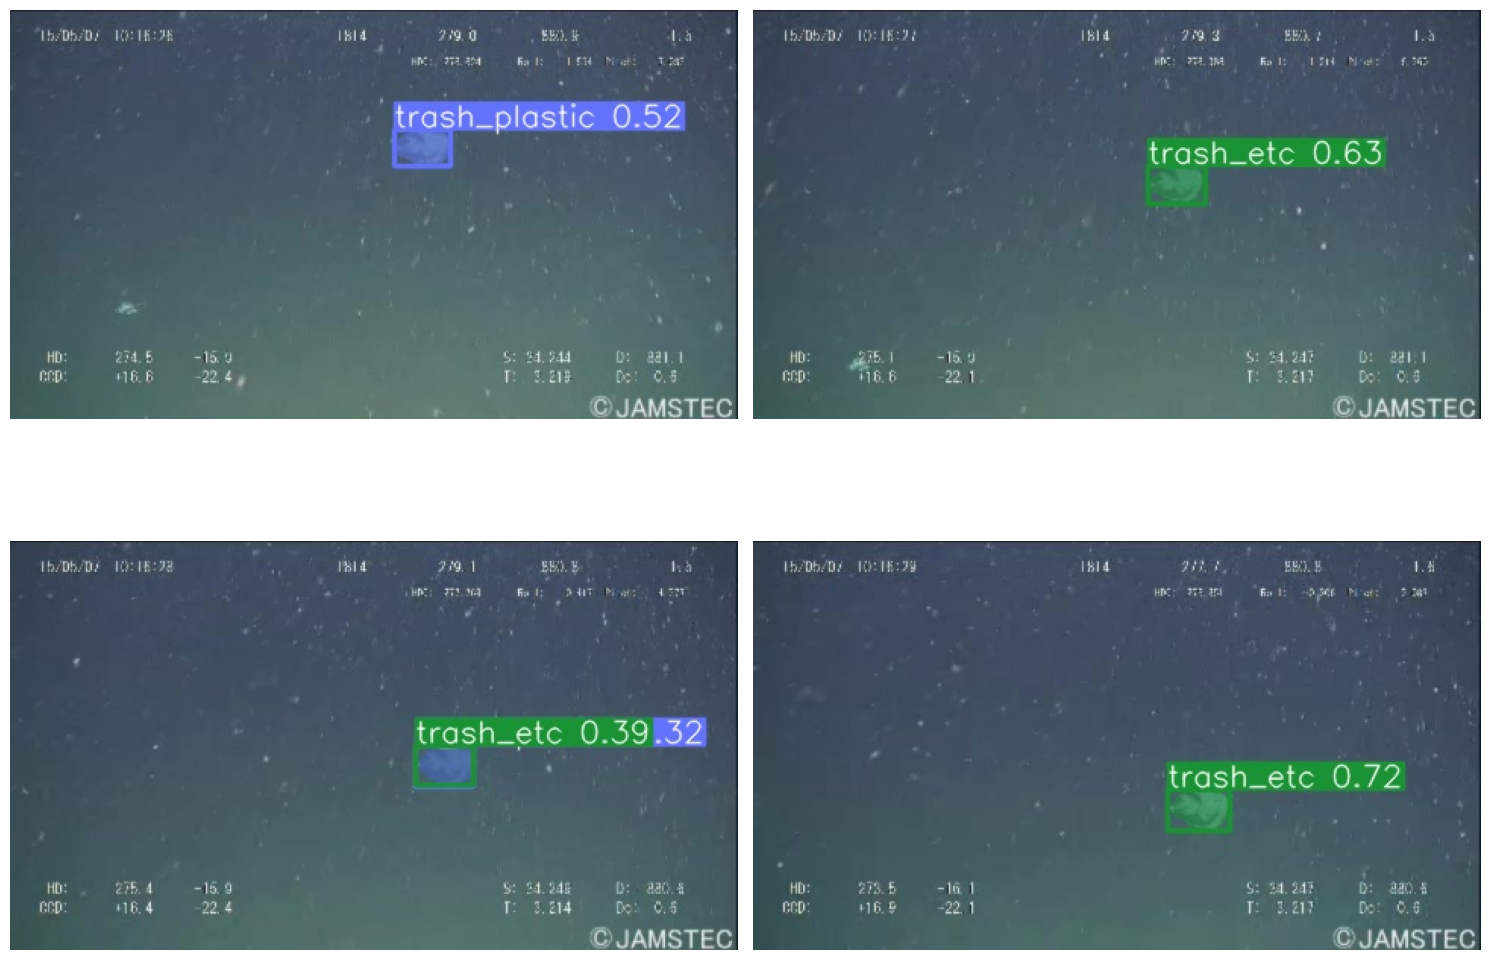

In [ ]:
visualize('runs/segment/yolov8m_predict')

In [ ]:
cwd = os.getcwd()
print(cwd)

/content/drive/MyDrive/Trash_detect


In [ ]:
# @title To test and get result, Extract data in excel
import os
import pandas as pd
from ultralytics import YOLO

# Load your YOLOv8 model
model = YOLO('/content/drive/MyDrive/Trash_detect/runs/segment/yolov8m-seg/weights/best.pt')

# Specify the directory containing your images
image_dir = '/content/drive/MyDrive/Trash_detect/trash_inst_material/val/images'

# Get a list of all image files in the directory
image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]

# Initialize an empty DataFrame
df = pd.DataFrame(columns=['image', 'label', 'confidence', 'xmin', 'ymin', 'xmax', 'ymax'])

# Loop through each image and run the YOLOv8 model
for image_path in image_paths:
    # Run the model on the image and get the detection results
    results = model(image_path)

    # Loop through each detection and store the results in the DataFrame
    for result in results:
        for box in result.boxes:
            # Get the bounding box coordinates
            xmin, ymin, xmax, ymax = box.xyxy[0].tolist()

            # Get the class label and confidence score
            label = model.names[int(box.cls)]
            confidence = float(box.conf)

            # Append the result to the DataFrame
            row=pd.DataFrame([{'image': os.path.basename(image_path), 'label': label, 'confidence': confidence, 'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax}])
            df = pd.concat([df,row], ignore_index=True)

# Save DataFrame to an Excel file
df.to_excel('predicted_labels.xlsx', index=False)


In [ ]:
# @title [Optional] For a single video
import os
import cv2
import pandas as pd
from ultralytics import YOLO

# Load your YOLOv8 model (replace 'yolov8_model.pt' with the actual path to your trained model)
model = YOLO('/content/drive/MyDrive/Trash_detect/runs/segment/yolov8m-seg/weights/best.pt')

# Specify the path to your video file
video_path = '/content/drive/MyDrive/Trash_detect/trash_segment_inference_data/bali.mp4'

# Initialize a list to store the results
results = []

# Open the video file
cap = cv2.VideoCapture(video_path)

# Get the total number of frames in the video
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

frame_id = 0

# Loop through each frame of the video
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Run the model on the current frame and get the detection results
    predictions = model(frame)

    # Loop through each prediction and store the results in the list of dictionaries
    for pred in predictions:
        # pred.boxes.xyxy: Tensor of shape (n, 4) containing [x1, y1, x2, y2] for each bounding box
        # pred.boxes.conf: Tensor of shape (n,) containing the confidence score for each bounding box
        # pred.boxes.cls: Tensor of shape (n,) containing the class index for each bounding box
        for i in range(len(pred.boxes)):
            result = {
                'frame_id': frame_id,
                'label': model.names[int(pred.boxes.cls[i])],
                'percent': float(pred.boxes.conf[i])
            }
            results.append(result)

    frame_id += 1

# Release the video capture object
cap.release()

# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(results)

# Display the DataFrame
print(df)

# Save the DataFrame to a CSV file
df.to_csv('video_detection_results.csv', index=False)


Streaming output truncated to the last 5000 lines.

0: 384x640 2 rovs, 2 animal_shellss, 16.2ms
Speed: 2.3ms preprocess, 16.2ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 animal_shellss, 19.0ms
Speed: 1.6ms preprocess, 19.0ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 rov, 1 animal_shells, 14.5ms
Speed: 1.6ms preprocess, 14.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 rov, 2 animal_shellss, 14.3ms
Speed: 1.9ms preprocess, 14.3ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 animal_shellss, 1 trash_wood, 16.7ms
Speed: 2.4ms preprocess, 16.7ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 animal_shellss, 1 trash_wood, 15.3ms
Speed: 3.5ms preprocess, 15.3ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 animal_shellss, 21.7ms
Speed: 2.1ms preprocess, 21.7ms inference, 2.4ms postproces

In [ ]:
# @title For Video Dataset, to extract results and save in excel
import os
import cv2
import pandas as pd
from ultralytics import YOLO

# Load your YOLOv8 model (replace 'yolov8_model.pt' with the actual path to your trained model)
model = YOLO('/content/drive/MyDrive/Trash_detect/runs/segment/yolov8m-seg/weights/best.pt')

# Specify the directory containing your video files
video_dir = '/content/drive/MyDrive/Trash_detect/trash_segment_inference_data/'

# Get a list of all video files in the directory
video_files = [f for f in os.listdir(video_dir) if f.endswith('.mp4')]

for video_file in video_files:
    video_path = os.path.join(video_dir, video_file)
    print(f'Processing video: {video_path}')

    # Initialize a list to store the results
    results = []

    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Get the total number of frames in the video
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_id = 0

    # Loop through each frame of the video
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Run the model on the current frame and get the detection results
        predictions = model(frame)

        # Loop through each prediction and store the results in the list of dictionaries
        for pred in predictions:
            for i in range(len(pred.boxes)):
                result = {
                    'frame_id': frame_id,
                    'label': model.names[int(pred.boxes.cls[i])],
                    'percent': float(pred.boxes.conf[i])
                }
                results.append(result)

        frame_id += 1

    # Release the video capture object
    cap.release()

    # Convert the list of dictionaries to a pandas DataFrame
    df = pd.DataFrame(results)

    # Define the CSV file name based on the video file name
    csv_file_name = os.path.splitext(video_file)[0] + '_detection_results.csv'
    csv_file_path = os.path.join(video_dir, csv_file_name)

    # Save the DataFrame to a CSV file
    df.to_csv(csv_file_path, index=False)
    print(f'Saved results to: {csv_file_path}')


Streaming output truncated to the last 5000 lines.
Speed: 1.8ms preprocess, 14.6ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 animal_shellss, 15.7ms
Speed: 2.0ms preprocess, 15.7ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 animal_shellss, 14.1ms
Speed: 1.8ms preprocess, 14.1ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 rov, 2 animal_shellss, 15.9ms
Speed: 1.8ms preprocess, 15.9ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 animal_shellss, 14.7ms
Speed: 1.9ms preprocess, 14.7ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 rovs, 2 animal_shellss, 15.6ms
Speed: 1.9ms preprocess, 15.6ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 animal_shellss, 15.0ms
Speed: 1.8ms preprocess, 15.0ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 rov, 1 animal_shell

In [ ]:
# @title Optional
import pandas as pd
from ultralytics import YOLO

# Load your YOLOv8 model (replace 'path_to_your_model' with the actual path to your trained model)
model = YOLO('/content/drive/MyDrive/Trash_detect/runs/segment/yolov8m-seg/weights/best.pt')

# List of image paths to run the model on
image_dir = '/content/drive/MyDrive/Trash_detect/trash_inst_material/val/images'

# Get a list of all image files in the directory
image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]
# Initialize an empty list to store the results
results = []

# Loop through each image and run the YOLOv8 model
for image_path in image_paths:
    # Run the model on the image and get the detection results
    predictions = model(image_path)

    # Loop through each prediction and store the results in the list of dictionaries
    for pred in predictions:
        # pred.boxes.xyxy: Tensor of shape (n, 4) containing [x1, y1, x2, y2] for each bounding box
        # pred.boxes.conf: Tensor of shape (n,) containing the confidence score for each bounding box
        # pred.boxes.cls: Tensor of shape (n,) containing the class index for each bounding box
        for i in range(len(pred.boxes)):
            result = {
                'imgname': os.path.basename(image_path),
                'label': model.names[int(pred.boxes.cls[i])],
                'percent': float(pred.boxes.conf[i])
            }
            results.append(result)
# Convert the list of dictionaries to a pandas DataFrame
df = pd.DataFrame(results)

# Display the DataFrame
print(df)

# Save the DataFrame to a CSV file
df.to_csv('detection_results.csv', index=False)


In [ ]:
cd '/content/drive/'

## Inference on Videos

For one final testing, let's run inference on videos.

In [ ]:
!yolo predict \
model='runs/segment/yolov8m-seg/weights/best.pt' \
source='trash_segment_inference_data/manythings.mp4' \
name='yolov8m_predict_videos1' \
exist_ok=True \
save=True

Ultralytics YOLOv8.1.42 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8m-seg summary (fused): 245 layers, 27231648 parameters, 0 gradients, 110.0 GFLOPs

video 1/1 (frame 1/1168) /content/drive/MyDrive/Trash_detect/trash_segment_inference_data/manythings.mp4: 480x640 (no detections), 134.4ms
video 1/1 (frame 2/1168) /content/drive/MyDrive/Trash_detect/trash_segment_inference_data/manythings.mp4: 480x640 (no detections), 34.8ms
video 1/1 (frame 3/1168) /content/drive/MyDrive/Trash_detect/trash_segment_inference_data/manythings.mp4: 480x640 (no detections), 34.8ms
video 1/1 (frame 4/1168) /content/drive/MyDrive/Trash_detect/trash_segment_inference_data/manythings.mp4: 480x640 2 trash_etcs, 34.8ms
video 1/1 (frame 5/1168) /content/drive/MyDrive/Trash_detect/trash_segment_inference_data/manythings.mp4: 480x640 1 trash_etc, 31.4ms
video 1/1 (frame 6/1168) /content/drive/MyDrive/Trash_detect/trash_segment_inference_data/manythings.mp4: 480x640 1 trash_etc, 31.3ms
video 

Even the Extra Large model, is running at more than 28 FPS on the Tesla T4 GPU which is more than real-time. This is really impressive.